### 파일 저장 형식 저장

In [1]:
date = '251217'
token_method = 'kiwi' # 'kiwi'
clustering_method = 'kmeans' # kmeans; agglomerative; hdbscan+umap
ver = 1
memo = '5yr'

##### 샘플 데이터

In [2]:
import pandas as pd

In [3]:
# df = pd.read_excel('./요리 전중후_통합_251211_ver3.xlsx')
df = pd.read_excel('./crawling_integrated_5yr_251212_ver3.xlsx')
df.head(5)

,src,Date,Date_YYYY,Title,Contents
0,82cook,20251207,2025,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",[URL]\n\n진짜 장보기 무섭네요\n
1,82cook,20251206,2025,사람은 역시 자기가 경험한 만큼 세상을 보네요.,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ..."
2,82cook,20251202,2025,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...
3,82cook,20251116,2025,장보기(쿠팡 식재료 주문) 봐주세요,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...
4,82cook,20251112,2025,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...


# ◆ 1. 데이터 전처리하기
- 1.1. 행 중복 제거
- 1.2. 특수문자 및 숫자 제거

### 1.1. 행 중복 제거

In [4]:
df = df.drop_duplicates()
df.head()

,src,Date,Date_YYYY,Title,Contents
0,82cook,20251207,2025,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",[URL]\n\n진짜 장보기 무섭네요\n
1,82cook,20251206,2025,사람은 역시 자기가 경험한 만큼 세상을 보네요.,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ..."
2,82cook,20251202,2025,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...
3,82cook,20251116,2025,장보기(쿠팡 식재료 주문) 봐주세요,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...
4,82cook,20251112,2025,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...


### 1.2. 특수문자 및 숫자 제거
    *정규표현식 사용

In [5]:
import re
from tqdm import tqdm

In [6]:
def re_pattern(string):
    pattern = re.compile(r'[^a-zA-Z가-힣\s\.\!\?]') # "알파벳 대소문자, 한글, 공백, 마침표(.), 느낌표(!), 물음표(?)" 이외 제거
    string = re.sub(pattern, ' ', string)
    
    pattern2 = re.compile(r'\s+')
    result = re.sub(pattern2, ' ', string)
    
    return result

In [7]:
df['Contents_pre1'] = df['Contents'].apply(lambda x: re_pattern(x))
df.head()

,src,Date,Date_YYYY,Title,Contents,Contents_pre1
0,82cook,20251207,2025,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",[URL]\n\n진짜 장보기 무섭네요\n,URL 진짜 장보기 무섭네요
1,82cook,20251206,2025,사람은 역시 자기가 경험한 만큼 세상을 보네요.,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ...",고등 학년 올라가는 딸. 기숙생활하는데 여기 글 올라온 것들 보니까 고등생활이 이리...
2,82cook,20251202,2025,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...,. 신선제품 새벽배송 마켓컬리 상품의 질이 좋고 트렌디한 식재료 많음 URL 현재...
3,82cook,20251116,2025,장보기(쿠팡 식재료 주문) 봐주세요,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데 일도 ...
4,82cook,20251112,2025,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...,최근 몇 달 간 이상이 그럴거같아요 마트는 근처에 홈플이 있는데 최근에 행사 상품들...


# ◆ 2. 데이터 형태소 분리하기
* 2.1 불용어적용 및 형태소 분리
* 2.2 데이터 프레임에 추가

In [8]:
# !pip install konlpy
# from konlpy.tag import Okt
# okt=Okt()

In [9]:
from kiwipiepy import Kiwi # 형태소 분석기
kiwi = Kiwi()

### 2.1. 불용어적용 및 형태소 분리
    *제공되는 한국어 불용어 파일 사용(ko-stopwords.csv)

In [10]:
stopwords_df = pd.read_csv('./ko-stopwords.csv')
stopwords_df

,stopwords
0,가
1,가까스로
2,가령
3,각
4,각각
...,...
600,진짜
601,두
602,게
603,요


In [11]:
stopwords = set(stopwords_df['stopwords'])
stopwords


{'가',
 '가까스로',
 '가령',
 '각',
 '각각',
 '각자',
 '각종',
 '갖고말하자면',
 '같다',
 '같이',
 '개의치않고',
 '거니와',
 '거바',
 '거의',
 '것',
 '것과 같이',
 '것들',
 '게',
 '게다가',
 '게우다',
 '겨우',
 '견지에서',
 '결과에 이르다',
 '결국',
 '결론을 낼 수 있다',
 '겸사겸사',
 '고려하면',
 '고로',
 '곧',
 '공동으로',
 '과',
 '과연',
 '관계가 있다',
 '관계없이',
 '관련이 있다',
 '관하여',
 '관한',
 '관해서는',
 '구',
 '구체적으로',
 '구토하다',
 '그',
 '그들',
 '그때',
 '그래',
 '그래도',
 '그래서',
 '그러나',
 '그러니',
 '그러니까',
 '그러면',
 '그러므로',
 '그러한즉',
 '그런 까닭에',
 '그런데',
 '그런즉',
 '그럼',
 '그럼에도 불구하고',
 '그렇게 함으로써',
 '그렇지',
 '그렇지 않다면',
 '그렇지 않으면',
 '그렇지만',
 '그렇지않으면',
 '그리고',
 '그리하여',
 '그만이다',
 '그에 따르는',
 '그위에',
 '그저',
 '그중에서',
 '그치지 않다',
 '근거로',
 '근거하여',
 '기대여',
 '기점으로',
 '기준으로',
 '기타',
 '까닭으로',
 '까악',
 '까지',
 '까지 미치다',
 '까지도',
 '꽈당',
 '끙끙',
 '끼익',
 '나',
 '나머지는',
 '남들',
 '남짓',
 '너',
 '너희',
 '너희들',
 '네',
 '넷',
 '년',
 '논하지 않다',
 '놀라다',
 '누가 알겠는가',
 '누구',
 '다른',
 '다른 방면으로',
 '다만',
 '다섯',
 '다소',
 '다수',
 '다시 말하자면',
 '다시말하면',
 '다음',
 '다음에',
 '다음으로',
 '단지',
 '답다',
 '당신',
 '당장',
 '대로 하다',
 '대하면',
 '대하여',
 '대해 말하자면',
 '대해서',
 

In [12]:
def okt_pos_tagging(string):
    pos_words = okt.pos(string, stem=True, norm=True) # 어근 O, 정규화 O
    result = [word for word, tag in pos_words if (word not in stopwords) and (tag in ['Noun', 'Adjective', 'Verb'])]
    return result

In [13]:
def kiwi_pos_tagging(string):
    try:
        token = kiwi.tokenize(string)
    except: # 인코딩 문제 있을때
        string = str(string)
        string = string.encode("utf-8", errors="ignore").decode("utf-8", errors="ignore")
        token = kiwi.tokenize(string)
    result = [t.form for t in token if (t.tag=='NNG' or t.tag=='NNP' or t.tag=='VV' or t.tag=='VA') and (t.form not in stopwords)]
    
    return result

In [14]:
# okt_pos_tagging(df['Contents_pre1'][0])
kiwi_pos_tagging(df['Contents_pre1'][0])

['장보기']

### 2.2 데이터 프레임에 추가

In [15]:
tqdm.pandas() # pandas apply 함수 적용 시 tqdm 함수 사용 가능하도록 설정

In [16]:
# df['tokenized'] = df['Contents_pre1'].progress_apply(okt_pos_tagging)
df['tokenized'] = df['Contents_pre1'].progress_apply(kiwi_pos_tagging)
df.head()

100%|██████████| 41338/41338 [04:52<00:00, 141.55it/s]


,src,Date,Date_YYYY,Title,Contents,Contents_pre1,tokenized
0,82cook,20251207,2025,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",[URL]\n\n진짜 장보기 무섭네요\n,URL 진짜 장보기 무섭네요,[장보기]
1,82cook,20251206,2025,사람은 역시 자기가 경험한 만큼 세상을 보네요.,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ...",고등 학년 올라가는 딸. 기숙생활하는데 여기 글 올라온 것들 보니까 고등생활이 이리...,"[고등, 학년, 올라가, 딸, 기숙, 생활, 글, 올라오, 보, 고등, 생활, 힘들..."
2,82cook,20251202,2025,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...,. 신선제품 새벽배송 마켓컬리 상품의 질이 좋고 트렌디한 식재료 많음 URL 현재...,"[신선, 제품, 새벽, 배송, 마켓, 컬리, 상품, 질, 좋, 트렌디, 식재료, 많..."
3,82cook,20251116,2025,장보기(쿠팡 식재료 주문) 봐주세요,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데 일도 ...,"[피곤, 이유, 배달, 시키, 먹, 카드, 값, 나오, 건강, 좋, 쉬, 되, 식비..."
4,82cook,20251112,2025,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...,최근 몇 달 간 이상이 그럴거같아요 마트는 근처에 홈플이 있는데 최근에 행사 상품들...,"[최근, 간, 같, 마트, 근처, 홈플, 있, 최근, 행사, 상품, 좋, 괜찮, 있..."


# ◆ 3. 벡터화
* 3.1 doc2vec 준비(문서의 순서 매기기)
* 3.2 doc2vec 학습시키기
* 3.3 벡터 값 데이터 프레임에 추가

In [17]:
# !pip install gensim

In [18]:
import gensim #자연어 처리 및 토픽 모델링을 위한 라이브러리
from gensim.models.doc2vec import TaggedDocument
from gensim.models import Doc2Vec

### 3.1 doc2vec 준비
    - word2vec은 단어 하나를 하나의 vector화
    - doc2vec은 문서 하나를 하나의 vector화

In [19]:
tagged_corpus_list = []
for n, i in enumerate(df['tokenized']):
    tag = f"document{n}"
    tagged_corpus_list.append(TaggedDocument(tags=[tag], words= i))

In [20]:
tagged_corpus_list[0]

TaggedDocument(words=['장보기'], tags=['document0'])

### 3.2 doc2vec 학습시키기
    <model 하이퍼파라미터 값>
    # vector_size : 생성할 문서 벡터의 크기
    # alpha: 모델 학습시 초기 학습률 0.025는 일반적으로 사용됨
    # min_alpha: 학습 과정에서 alpha 값을 이 값으로 줄여나가게 됩니다
    # window : 문맥 윈도우 크기, 주변 몇개의 단어의 문맥을 고려하여 학습하는가

In [ ]:
model_doc2vec = Doc2Vec(vector_size = 300, # hyper-p
                        alpha = 0.025, # hyper-p
                        min_alpha = 0.01, # hyper-p
                        window = 3, # hyper-p
                        min_count = 1, # 최소 등장 횟수 # hyper-p
                        dm = 1) # hyper-p

In [22]:
# 단어사전 생성
model_doc2vec.build_vocab(tagged_corpus_list)

In [23]:
# 학습
model_doc2vec.train(tagged_corpus_list,
                    total_examples = model_doc2vec.corpus_count,
                    epochs = 100) # hyper-p

### 3.3 벡터 값 데이터 프레임에 추가

In [24]:
vector_list = []
for i in range(len(df)):
    doc2vec = model_doc2vec.dv[f'document{i}']
    vector_list.append(doc2vec)

In [25]:
df['vector'] = vector_list
df.head()

,src,Date,Date_YYYY,Title,Contents,Contents_pre1,tokenized,vector
0,82cook,20251207,2025,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",[URL]\n\n진짜 장보기 무섭네요\n,URL 진짜 장보기 무섭네요,[장보기],"[0.037392814, -0.29459, 0.17511795, 0.12122115..."
1,82cook,20251206,2025,사람은 역시 자기가 경험한 만큼 세상을 보네요.,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ...",고등 학년 올라가는 딸. 기숙생활하는데 여기 글 올라온 것들 보니까 고등생활이 이리...,"[고등, 학년, 올라가, 딸, 기숙, 생활, 글, 올라오, 보, 고등, 생활, 힘들...","[0.82459605, -0.9173704, 0.19989485, -0.170994..."
2,82cook,20251202,2025,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...,. 신선제품 새벽배송 마켓컬리 상품의 질이 좋고 트렌디한 식재료 많음 URL 현재...,"[신선, 제품, 새벽, 배송, 마켓, 컬리, 상품, 질, 좋, 트렌디, 식재료, 많...","[0.06494634, -1.4037112, 2.0892603, 0.6447389,..."
3,82cook,20251116,2025,장보기(쿠팡 식재료 주문) 봐주세요,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데 일도 ...,"[피곤, 이유, 배달, 시키, 먹, 카드, 값, 나오, 건강, 좋, 쉬, 되, 식비...","[-0.4153514, 1.6046768, 0.17744538, 1.8639125,..."
4,82cook,20251112,2025,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...,최근 몇 달 간 이상이 그럴거같아요 마트는 근처에 홈플이 있는데 최근에 행사 상품들...,"[최근, 간, 같, 마트, 근처, 홈플, 있, 최근, 행사, 상품, 좋, 괜찮, 있...","[-1.3283105, -0.40097845, 0.9471684, -0.459290..."


In [26]:
# pickle 형식으로 저장
import pickle

# with open(f'./results/vector_df_{date}_{token_method}_{ver}_{memo}.pkl', 'wb') as f:
with open(f'./results/vector_df_{date}_{token_method}_{clustering_method}_{ver}_{memo}.pkl', 'wb') as f:
    pickle.dump(df, f)

In [27]:
# pickle load
# with open(f'./results/vector_df_{date}_{token_method}_{ver}_{memo}.pkl', 'rb') as f:
with open(f'./results/vector_df_{date}_{token_method}_{clustering_method}_{ver}_{memo}.pkl', 'rb') as f:
    df = pickle.load(f)
    
df.head()

,src,Date,Date_YYYY,Title,Contents,Contents_pre1,tokenized,vector
0,82cook,20251207,2025,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",[URL]\n\n진짜 장보기 무섭네요\n,URL 진짜 장보기 무섭네요,[장보기],"[0.037392814, -0.29459, 0.17511795, 0.12122115..."
1,82cook,20251206,2025,사람은 역시 자기가 경험한 만큼 세상을 보네요.,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ...",고등 학년 올라가는 딸. 기숙생활하는데 여기 글 올라온 것들 보니까 고등생활이 이리...,"[고등, 학년, 올라가, 딸, 기숙, 생활, 글, 올라오, 보, 고등, 생활, 힘들...","[0.82459605, -0.9173704, 0.19989485, -0.170994..."
2,82cook,20251202,2025,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...,. 신선제품 새벽배송 마켓컬리 상품의 질이 좋고 트렌디한 식재료 많음 URL 현재...,"[신선, 제품, 새벽, 배송, 마켓, 컬리, 상품, 질, 좋, 트렌디, 식재료, 많...","[0.06494634, -1.4037112, 2.0892603, 0.6447389,..."
3,82cook,20251116,2025,장보기(쿠팡 식재료 주문) 봐주세요,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데 일도 ...,"[피곤, 이유, 배달, 시키, 먹, 카드, 값, 나오, 건강, 좋, 쉬, 되, 식비...","[-0.4153514, 1.6046768, 0.17744538, 1.8639125,..."
4,82cook,20251112,2025,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...,최근 몇 달 간 이상이 그럴거같아요 마트는 근처에 홈플이 있는데 최근에 행사 상품들...,"[최근, 간, 같, 마트, 근처, 홈플, 있, 최근, 행사, 상품, 좋, 괜찮, 있...","[-1.3283105, -0.40097845, 0.9471684, -0.459290..."


# ◆ 4. K-Means 클러스터링
* 4.1 ward 기준으로 덴드로그램 그려보기
* 4.2 sse 지수 확인해서 클러스터수 정하기
* 4.3 가장 적절한 클러스터링 갯수 df에 삽입

### 4.1 ward 기준으로 덴드로그램 그려보기

In [28]:
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt

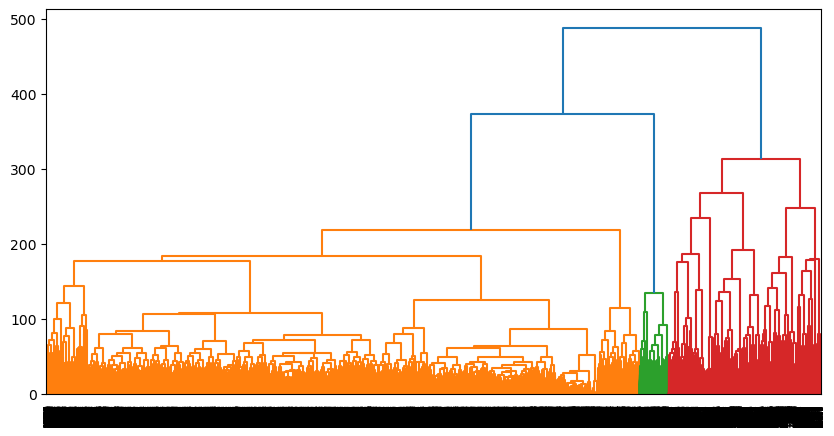

In [29]:
model_linkage = linkage(list(df['vector']), 'ward')

plt.figure(figsize=(10, 5))
dendrogram(model_linkage,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts = False)

plt.show()

### 4.2 sse 지수 확인해서 클러스터수 정하기

In [30]:
# !pip install scikit-learn

In [31]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [32]:
X = list(df['vector'])

In [33]:
# 1~10개 클러스터에 대한 SSE 계산 후 리스트
k_range = range(2, 15)
sse = []
for k in tqdm(k_range):
  kmeans = KMeans(n_clusters=k, random_state=21)
  kmeans.fit(X)
  sse.append(kmeans.inertia_)

100%|██████████| 13/13 [00:04<00:00,  2.79it/s]


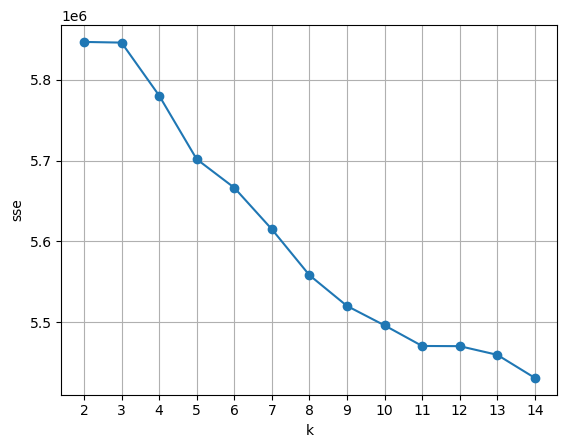

In [34]:
# 시각화
plt.plot(k_range, sse, marker='o')
plt.grid()
plt.xticks(k_range) # x축 눈금 지정
plt.xlabel("k")
plt.ylabel('sse')
plt.show()

In [35]:
result = pd.DataFrame([k_range, sse]).T
result.columns = ['n_cluster', 'sse']
result

,n_cluster,sse
0,2.0,5.847077e+06
1,3.0,5.846233e+06
2,4.0,5.780680e+06
3,5.0,5.701818e+06
4,6.0,5.666459e+06
5,7.0,5.615036e+06
6,8.0,5.558123e+06
7,9.0,5.519987e+06
8,10.0,5.495900e+06
9,11.0,5.470387e+06


In [36]:
# 객체 생성
nc = 3
km_model = KMeans(n_clusters = nc, random_state = 42)

# 모델 학습
km_model.fit(X)

# 결과 확인
labels = km_model.labels_

In [37]:
df['cluster'] = labels
df.head()

,src,Date,Date_YYYY,Title,Contents,Contents_pre1,tokenized,vector,cluster
0,82cook,20251207,2025,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",[URL]\n\n진짜 장보기 무섭네요\n,URL 진짜 장보기 무섭네요,[장보기],"[0.037392814, -0.29459, 0.17511795, 0.12122115...",2
1,82cook,20251206,2025,사람은 역시 자기가 경험한 만큼 세상을 보네요.,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ...",고등 학년 올라가는 딸. 기숙생활하는데 여기 글 올라온 것들 보니까 고등생활이 이리...,"[고등, 학년, 올라가, 딸, 기숙, 생활, 글, 올라오, 보, 고등, 생활, 힘들...","[0.82459605, -0.9173704, 0.19989485, -0.170994...",2
2,82cook,20251202,2025,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...,. 신선제품 새벽배송 마켓컬리 상품의 질이 좋고 트렌디한 식재료 많음 URL 현재...,"[신선, 제품, 새벽, 배송, 마켓, 컬리, 상품, 질, 좋, 트렌디, 식재료, 많...","[0.06494634, -1.4037112, 2.0892603, 0.6447389,...",2
3,82cook,20251116,2025,장보기(쿠팡 식재료 주문) 봐주세요,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데 일도 ...,"[피곤, 이유, 배달, 시키, 먹, 카드, 값, 나오, 건강, 좋, 쉬, 되, 식비...","[-0.4153514, 1.6046768, 0.17744538, 1.8639125,...",2
4,82cook,20251112,2025,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...,최근 몇 달 간 이상이 그럴거같아요 마트는 근처에 홈플이 있는데 최근에 행사 상품들...,"[최근, 간, 같, 마트, 근처, 홈플, 있, 최근, 행사, 상품, 좋, 괜찮, 있...","[-1.3283105, -0.40097845, 0.9471684, -0.459290...",2


In [38]:
df['cluster'].value_counts()

cluster
2    31386
1     7912
0     2040
Name: count, dtype: int64

### PCA

In [39]:
df_v = df[['vector', 'cluster']]
df_v.head(5)

,vector,cluster
0,"[0.037392814, -0.29459, 0.17511795, 0.12122115...",2
1,"[0.82459605, -0.9173704, 0.19989485, -0.170994...",2
2,"[0.06494634, -1.4037112, 2.0892603, 0.6447389,...",2
3,"[-0.4153514, 1.6046768, 0.17744538, 1.8639125,...",2
4,"[-1.3283105, -0.40097845, 0.9471684, -0.459290...",2


In [40]:
import numpy as np
from sklearn.decomposition import PCA

# 1) vector 컬럼을 (n_samples, 300) 행렬로 만들기
X = np.vstack(df_v['vector'].values)   # shape: (N, 300)

# 2) cluster 라벨
labels = df_v['cluster'].values        # shape: (N,)

# 3) PCA로 2차원으로 축소
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X)           # shape: (N, 2)

# 4) 결과를 df_v에 붙여두면 나중에 분석하기 편함
df_v['pca1'] = X_pca[:, 0]
df_v['pca2'] = X_pca[:, 1]

/tmp/ipykernel_2505280/1087694513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_v['pca1'] = X_pca[:, 0]
/tmp/ipykernel_2505280/1087694513.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_v['pca2'] = X_pca[:, 1]


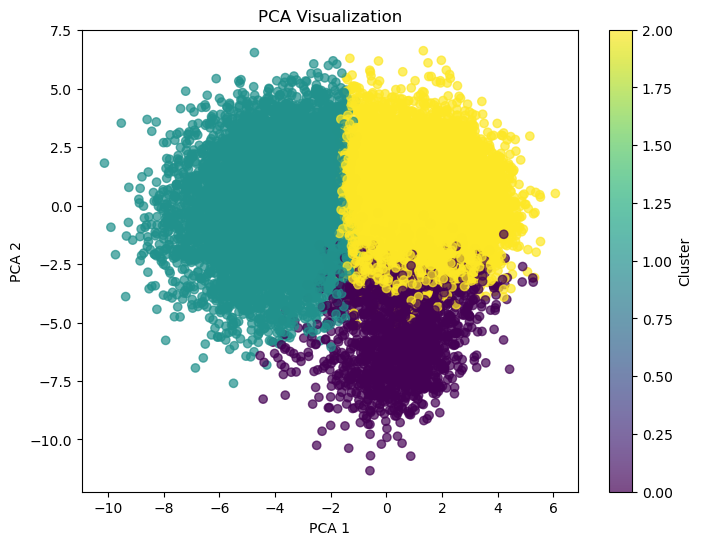

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_v['pca1'], df_v['pca2'],
                      c=df_v['cluster'], alpha=0.7)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA Visualization")

cbar = plt.colorbar(scatter)
cbar.set_label("Cluster")

plt.show()

# ◆ 5. 해석하기:TF-IDF
* 문서 내에서 어떤 단어가 얼마나 중요한지를 평가하는 데 사용되는 방법
* 5.1 TF-IDF 계산
* 5.2 데이터프레임으로 만들고 정렬하기

### 5.1 TF-idf 계산
* 각 클러스터 마다 tfidf가 높은 워드들 찾기
* 각 클러스터들을 하나의 문서로 가정하여 tf-idf 값 추출

In [42]:
from collections import Counter
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

In [43]:
df['cluster'].unique()

array([2, 1, 0], dtype=int32)

In [56]:
df['cluster'].value_counts()

cluster
2    31386
1     7912
0     2040
Name: count, dtype: int64

In [44]:
all_document = []
for i in df['cluster'].unique():
    print(i)
    pos_tagging = df[df['cluster'] == i]['tokenized']
    
    document = ''
    for pos in pos_tagging:
        doc = " ".join(pos) + " "
        document += doc
        
    all_document.append(document)

2
1
0


In [45]:
len(all_document[0])

4507203

In [46]:
# TF-IDF 벡터라이저 선언
vectorizer = TfidfVectorizer()
# TF-IDF 매트릭스 핏
tfidf_matrix = vectorizer.fit_transform(all_document)

In [47]:
# 키워드 도출
feature_name = vectorizer.get_feature_names_out()
feature_name

array(['ak플라자', 'a스스트모', 'b마틍', ..., '힛챠', '힝구', '힣히'], dtype=object)

In [48]:
# TF-IDF 값
tfidf_value = tfidf_matrix.toarray()

### 5.2 데이터프레임으로 만들고 정렬하기

In [49]:
# 데이터프레임으로 만들고 정렬하기
tfidf_df = pd.DataFrame(tfidf_value, columns=feature_name)
tfidf_df

,ak플라자,a스스트모,b마틍,cc,cj제일제당,c컬,c컬펌,c펌,d체라떼,gs리테일,...,힘펠,힘펠꺼,힙스터,힙시트,힙쓰러스트,힙어덕션,힙합,힛챠,힝구,힣히
0,0.000000,0.000000,0.000044,0.000000,0.000132,0.000067,0.000044,0.000044,0.000000,0.000000,...,0.000034,0.000044,0.000044,0.000044,0.000088,0.000044,0.000132,0.000044,0.000000,0.000044
1,0.000021,0.000021,0.000000,0.000248,0.000000,0.000016,0.000000,0.000000,0.000041,0.000041,...,0.000016,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000021,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [50]:
# 인덱스 부여 (cluster 번호)
tfidf_df.index = df['cluster'].unique()
tfidf_df

,ak플라자,a스스트모,b마틍,cc,cj제일제당,c컬,c컬펌,c펌,d체라떼,gs리테일,...,힘펠,힘펠꺼,힙스터,힙시트,힙쓰러스트,힙어덕션,힙합,힛챠,힝구,힣히
2,0.000000,0.000000,0.000044,0.000000,0.000132,0.000067,0.000044,0.000044,0.000000,0.000000,...,0.000034,0.000044,0.000044,0.000044,0.000088,0.000044,0.000132,0.000044,0.000000,0.000044
1,0.000021,0.000021,0.000000,0.000248,0.000000,0.000016,0.000000,0.000000,0.000041,0.000041,...,0.000016,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000021,0.000000
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [51]:
# 행열 전환
tfidf_df_T = tfidf_df.T
tfidf_df_T.head()

,2,1,0
ak플라자,0.000000,0.000021,0.0
a스스트모,0.000000,0.000021,0.0
b마틍,0.000044,0.000000,0.0
cc,0.000000,0.000248,0.0
cj제일제당,0.000132,0.000000,0.0


In [52]:
for i in tfidf_df_T.columns:
    # 점수 정렬
    tfidfvalue = tfidf_df_T[i].sort_values(ascending=False) # 내림차순 정렬
    # 데이터프레임으로 다시 변환
    data = {'tfidf_word': tfidfvalue.index, 'tfidf': tfidfvalue.values}
    data_df = pd.DataFrame(data)
    
    data_df.to_csv(f'./results/cluster{i}_tf_idf_{date}_{token_method}_{clustering_method}_{ver}_{memo}.csv', encoding='utf-8-sig')

In [53]:
# excel 파일로 저장
df.to_excel(f'./results/Actor_Clustering_n_{nc}_{date}_{token_method}_{clustering_method}_{ver}_{memo}.xlsx', index=False)

In [54]:
# pickle 파일로 저장
with open(f'./results/Actor_Clustering_n_{nc}_{date}_{token_method}_{clustering_method}_{ver}_{memo}.pkl', 'wb') as f:
    pickle.dump(df, f)

# 페르소나 분석

### 클러스터별 상위 tf-idf 단어(토큰) 추출

In [55]:
cluster_num = 0 # 0 ~ nc-1

tfidfvalue = tfidf_df_T[cluster_num].sort_values(ascending=False) # 오름차순 정렬
tfidfvalue = pd.DataFrame(tfidfvalue)
tfidfvalue.head(20)

,0
맛집,0.385905
맛있,0.362952
고기,0.238165
나오,0.227348
메뉴,0.172078
주문,0.158293
식사,0.151895
음식,0.141738
요리,0.121886
즐기,0.119181
